# SVG Swatches and Annotations

This notebook mirrors the plotting examples in `sections.ipynb`, but uses pystrat's SVG export path. Matplotlib still handles the layout, axes, labels, and data panels; pystrat replaces marked swatch rectangles and annotation placeholders with packaged SVG assets when saving whenever matching SVG files are available.


## How SVG Export Works

SVG export is implemented as a post-processing step around normal matplotlib figures. The plotting API stays close to the regular pystrat workflow: call `Section.plot(..., swatch_backend='svg')` to draw the section, then call `pystrat.savefig_svg(fig, path)` instead of `fig.savefig(...)`.

During plotting, pystrat still draws the colored bed rectangles in matplotlib. For each bed with a swatch code, it adds an invisible matplotlib rectangle with a stable SVG id such as `pystrat-swatch-627-12`. Those invisible rectangles mark where vector swatches should be placed, but they do not change the interactive matplotlib figure.

Annotations use the same idea in SVG mode. If a matching SVG symbol is available for a default annotation or a custom annotation path, pystrat places an invisible placeholder rectangle and `pystrat.savefig_svg(...)` replaces it with the annotation SVG at save time. If no matching SVG is available, the export falls back to the original raster annotation image.

When `pystrat.savefig_svg(...)` runs, it first asks matplotlib to save the whole figure as SVG. Then pystrat parses that SVG, finds the marked swatch and annotation placeholders, and replaces them with native SVG content built from the packaged USGS swatch files in `pystrat/swatches_svg` and the annotation symbol SVG files. This means axes, labels, and data panels remain matplotlib output, while the geologic swatches and available annotation symbols become scalable vector graphics.

The swatch catalog uses a slightly different export path. Catalog boxes show one complete scaled vector tile for each swatch, rather than a repeated pattern fill. That makes the catalog useful for browsing the original symbols, while section plots use repeated SVG patterns because beds need continuous pattern fills.

For backward compatibility, the default `swatch_backend='png'` keeps the historical raster behavior. Use `swatch_backend='svg'` when you plan to save with `pystrat.savefig_svg(...)`.


In [27]:
from pathlib import Path

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_src = Path('..', 'src').resolve()
if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))
for module_name in list(sys.modules):
    if module_name == 'pystrat' or module_name.startswith('pystrat.'):
        del sys.modules[module_name]

import pystrat
from IPython.display import SVG as SVGDisplay, display


In [28]:
output_dir = Path('example-data/vector-output')
output_dir.mkdir(parents=True, exist_ok=True)


## SVG Swatch Catalog

The catalog shows one complete vector tile for every packaged USGS swatch.


In [29]:
swatch_catalog_svg = output_dir / 'usgs_swatch_table_svg.svg'
pystrat.plot_svg_swatch_catalog(swatch_catalog_svg)
display(SVGDisplay(filename=str(swatch_catalog_svg)))
print(f'Wrote: {swatch_catalog_svg}')


Wrote: example-data/vector-output/usgs_swatch_table_svg.svg


## Group, Formation, Member Labels

Create a `Section` and `Style` from the same example data used by the standard sections notebook.


In [30]:
litho_df = pd.read_csv('example-data/lithostratigraphy.csv')
section_1 = pystrat.Section(
    litho_df['THICKNESS'],
    litho_df['FACIES'],
    units=litho_df[['GROUP', 'FORMATION']].values,
)

style_df = pd.read_csv('example-data/style.csv')
style_1 = pystrat.Style(
    style_df['facies'],
    style_df[['R', 'G', 'B']] / 255,
    style_df['width'],
    swatch_values=style_df['swatch'],
)


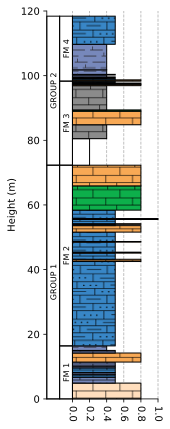

Wrote: example-data/vector-output/example_group_formation_labels_svg_swatches.svg


In [31]:
group_labels_svg = output_dir / 'example_group_formation_labels_svg_swatches.svg'
fig = plt.figure(figsize=(2, 7))
ax = plt.axes(ylim=[0, 120])
section_1.plot(
    style_1,
    ax=ax,
    label_units=True,
    unit_label_wid_tot=0.3,
    swatch_backend='svg',
)
pystrat.savefig_svg(fig, group_labels_svg)
plt.close(fig)
display(SVGDisplay(filename=str(group_labels_svg)))
print(f'Wrote: {group_labels_svg}')


## Annotations

Plotting annotations alongside stratigraphic columns is a conventional way of illustrating observations at given heights within the section, and `pystrat` is capable of plotting annotations.

Annotations must be added to the `pystrat.Section` object as a `pandas.DataFrame`. This DataFrame must contain *height* and *annotation* columns:
1. The *height* column contains the stratigraphic heights at which to plot the annotations.
2. The *annotation* column contains the names of annotations that are mapped to annotation graphics.

With `swatch_backend='svg'`, pystrat will embed vector annotation symbols in the saved SVG whenever a matching SVG asset is available for that annotation.


In [32]:
ann = pd.read_csv('example-data/annotations.csv')
section_2 = pystrat.Section(
    litho_df['THICKNESS'],
    litho_df['FACIES'],
    units=litho_df[['GROUP', 'FORMATION']].values,
    annotations=ann,
 )

style_2 = pystrat.Style(
    style_df['facies'],
    style_df[['R', 'G', 'B']] / 255,
    style_df['width'],
    swatch_values=style_df['swatch'],
    annotations=['stromatolite'],
)


### Default Annotations

The mapping between annotations and graphics is specified in a `pystrat.Style` object.

There are a couple ways of specifying which annotations to plot. `pystrat` comes with a small library of annotation illustrations. In SVG mode, `pystrat.Style.plot_default_annotations(backend='svg')` uses the packaged annotation SVG files so the exported figure stays fully vectorized.


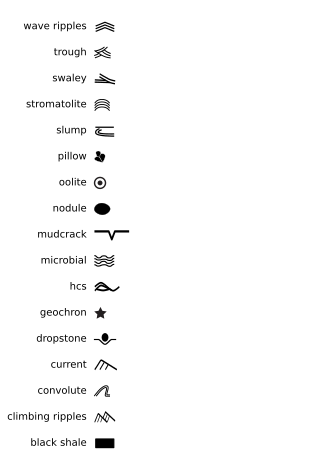

Wrote: example-data/vector-output/example_default_annotations_svg.svg


In [33]:
default_annotations_svg = output_dir / 'example_default_annotations_svg.svg'
fig, ax = plt.subplots(figsize=(4, 8))
pystrat.Style.plot_default_annotations(ax=ax, backend='svg')
pystrat.savefig_svg(fig, default_annotations_svg)
plt.close(fig)
display(SVGDisplay(filename=str(default_annotations_svg)))
print(f'Wrote: {default_annotations_svg}')


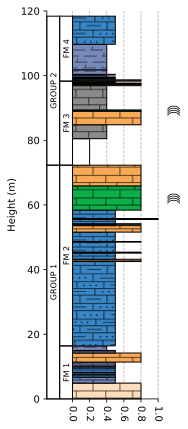

Wrote: example-data/vector-output/example_annotations_svg_swatches.svg


In [34]:
annotations_svg = output_dir / 'example_annotations_svg_swatches.svg'
fig = plt.figure(figsize=(2, 7))
ax = plt.axes(ylim=[0, 120])
section_2.plot(
    style_2,
    ax=ax,
    label_units=True,
    unit_label_wid_tot=0.3,
    swatch_backend='svg',
)
pystrat.savefig_svg(fig, annotations_svg)
plt.close(fig)
display(SVGDisplay(filename=str(annotations_svg)))
print(f'Wrote: {annotations_svg}')


In the section above, only stromatolites need to be annotated. A `Style` object with stromatolite annotations can be initialized by passing the `annotations=['stromatolite']` parameter.


### Custom Annotations

If an annotation is not available in the default library, custom graphics can be used by providing a dictionary that maps annotation names to `.png` or `.svg` paths. In this repository, the example path table points to the packaged annotation assets in `../src/pystrat/annotations`, parallel to the swatch assets, and the SVG backend automatically resolves matching vector annotation symbols where they exist.


/Users/yimingzhang/Github/pystrat/src/pystrat/pystrat.py:1473: UserWarning: Annotation pillow path ../../src/pystrat/annotations/pillow.png was not found. This annotation will not be plotted.
  warnings.warn(
/Users/yimingzhang/Github/pystrat/src/pystrat/pystrat.py:1473: UserWarning: Annotation geochron path ../../src/pystrat/annotations/geochron.png was not found. This annotation will not be plotted.
  warnings.warn(
/Users/yimingzhang/Github/pystrat/src/pystrat/pystrat.py:1473: UserWarning: Annotation dropstone path ../../src/pystrat/annotations/dropstone.png was not found. This annotation will not be plotted.
  warnings.warn(
/Users/yimingzhang/Github/pystrat/src/pystrat/pystrat.py:1473: UserWarning: Annotation hcs path ../../src/pystrat/annotations/hcs.png was not found. This annotation will not be plotted.
  warnings.warn(
/Users/yimingzhang/Github/pystrat/src/pystrat/pystrat.py:1473: UserWarning: Annotation wave ripples path ../../src/pystrat/annotations/wave ripples.png was not 

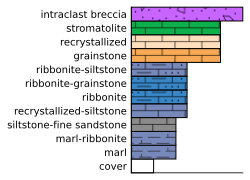

Wrote: example-data/vector-output/example_legend_svg_swatches.svg


In [49]:
ann_paths_df = pd.read_csv('example-data/annotation_paths.csv')
ann_paths_dict = dict(zip(ann_paths_df['name'], ann_paths_df['path']))
style_3 = pystrat.Style(
    style_df['facies'],
    style_df[['R', 'G', 'B']] / 255,
    style_df['width'],
    swatch_values=style_df['swatch'],
    annotations=ann_paths_dict,
)

legend_svg = output_dir / 'example_legend_svg_swatches.svg'
fig, ax = plt.subplots(1, 1, figsize=(2, 3))
style_3.plot_legend(ax=ax, swatch_backend='svg')
pystrat.savefig_svg(fig, legend_svg)
plt.close(fig)
display(SVGDisplay(filename=str(legend_svg)))
print(f'Wrote: {legend_svg}')


### Annotation Size

The size of the annotations can be controlled by the `annotation_height` parameter, which sets the annotation height in inches.


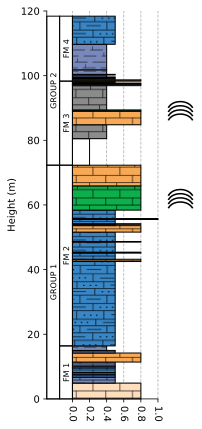

Wrote: example-data/vector-output/example_annotation_size_svg_swatches.svg


In [36]:
annotation_size_svg = output_dir / 'example_annotation_size_svg_swatches.svg'
fig = plt.figure(figsize=(2, 7))
ax = plt.axes(ylim=[0, 120])
section_2.plot(
    style_2,
    ax=ax,
    label_units=True,
    unit_label_wid_tot=0.3,
    annotation_height=0.3,
    swatch_backend='svg',
)
pystrat.savefig_svg(fig, annotation_size_svg)
plt.close(fig)
display(SVGDisplay(filename=str(annotation_size_svg)))
print(f'Wrote: {annotation_size_svg}')


## Style Compatibility

It is possible to check the compatibility of a `pystrat.Section` with a `pystrat.Style`.

Use the [`pystrat.Section.style_compatibility`](api/pystrat.rst#pystrat.pystrat.Section.style_compatibility) function.

This function checks that all facies present in the section are defined within the style object. If the section and the style object both have annotations, it will also check that the annotations in the section are defined in the style object.


In [37]:
section_2.style_compatibility(style_2)


True

If the style object does not have annotations but the facies are well-defined, then the check will pass and annotations would not be plotted.


In [38]:
section_2.style_compatibility(style_1)


True

## Stratigraphic Data

`pystrat` allows adding other types of data to `pystrat.Section` objects. There are three different types of data:
1. facies attributes: These data are defined on a per-bed basis; there must be one entry per bed in the section
2. data attributes: These data are defined at stratigraphic heights and are not explicitly tied to particular beds
3. generic attributes: These data are not tied to specific beds or stratigraphic height and instead describe other aspects of the section.


### Facies Attributes

Facies attributes are added to a section object with `pystrat.Section.add_facies_attribute`:


In [39]:
section_1.add_facies_attribute('lithology', litho_df['LITHOLOGY'])
section_1.lithology


array(['dolomite', 'dolomite', 'dolomite', 'dolomite', 'dolomite',
       'dolomite', 'dolomite', 'dolomite', 'dolomite', 'marl', 'dolomite',
       'dolomite', 'dolomite', 'dolomite', 'dolomite', 'dolomite',
       'dolomite', 'dolomite', 'dolomite', 'dolomite', 'dolomite',
       'dolomite', 'dolomite', 'dolomite', 'dolomite', 'cover',
       'siliciclastic', 'dolomite', 'dolomite', 'siliciclastic',
       'dolomite', 'dolomite', 'dolomite', 'marl', 'dolomite', 'dolomite',
       'limestone', 'marl', 'limestone', 'marl', 'limestone', 'marl',
       'marl', 'limestone'], dtype=object)

A dataframe representing the current state of the section object can be returned with `pystrat.Section.return_facies_dataframe`:


In [40]:
section_1.return_facies_dataframe().head()


,unit_number,thicknesses,base_height,top_height,facies,lithology
0,0,4.9,0.0,4.9,recrystallized,dolomite
1,1,1.8,4.9,6.7,ribbonite-siltstone,dolomite
2,2,0.8,6.7,7.5,ribbonite,dolomite
3,3,0.7,7.5,8.2,ribbonite-siltstone,dolomite
4,4,1.4,8.2,9.6,ribbonite,dolomite


### Data Attributes

Data attributes refer to stratigraphic observations that are not uniquely tied to beds in the stratigraphy. `pystrat` handles these data with the [`pystrat.Section.Data`](api/pystrat.rst#pystrat.pystrat.Section.Data) subclass.

This example uses carbonate chemostratigraphy.


In [41]:
chemo = pd.read_csv('example-data/chemostratigraphy.csv')
chemo.head()


,CARB_SAMPLE,CARB_HEIGHT,CARB_d13C,CARB_d18O,CARB_87Sr/86Sr,CARB_Al_ppm,CARB_Ca_ppm,CARB_Fe_ppm,CARB_Mg_ppm,CARB_Mn_ppm,CARB_Sr_ppm
0,T46-1.2,1.2,1.820429,0.130692,NaN,682.46931,313906.3927,293.408791,197499.6646,443.552746,539.226752
1,T46-2.1,2.1,1.597633,0.134841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T46-3.8,3.8,0.102096,-0.195867,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T46-5.9,5.9,1.090520,-1.066232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T46-7.1,7.1,2.194324,-0.630248,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Add the $\delta^{13}$C data using the `pystrat.Section.add_data_attribute()` method. This creates an instance of `pystrat.Section.Data`, and it is possible to add attributes to these objects as well.


In [42]:
section_1.add_data_attribute('d13C', chemo['CARB_HEIGHT'], chemo['CARB_d13C'])
section_1.d13C.add_height_attribute('sample', chemo['CARB_SAMPLE'])
section_1.d13C.return_data_dataframe().head()


,height,values,sample
0,1.2,1.820429,T46-1.2
1,2.1,1.597633,T46-2.1
2,3.8,0.102096,T46-3.8
3,5.9,1.090520,T46-5.9
4,7.1,2.194324,T46-7.1


#### Data Attribute Plotting

Data attributes can be plotted by directly accessing them from the section object. Alternatively, `pystrat` also provides [`pystrat.Section.plot_data_attribute`](api/pystrat.rst#pystrat.pystrat.Section.plot_data_attribute).

This example saves the same three-panel view as SVG so the stratigraphic column, swatches, and annotation symbols remain vectorized where SVG assets are available.


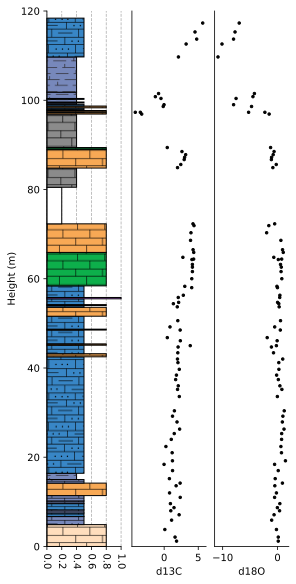

Wrote: example-data/vector-output/example_strat_data_svg_swatches.svg


In [43]:
section_1.add_data_attribute('d18O', chemo['CARB_HEIGHT'], chemo['CARB_d18O'])
section_1.d18O.add_height_attribute('sample', chemo['CARB_SAMPLE'])

strat_data_svg = output_dir / 'example_strat_data_svg_swatches.svg'
fig, ax = plt.subplots(1, 3, figsize=(4, 8), sharey=True, constrained_layout=True)
ax[0].set_ylim([0, 120])
section_1.plot(style_1, ax=ax[0], swatch_backend='svg')
section_1.plot_data_attribute('d13C', ax=ax[1])
section_1.plot_data_attribute('d18O', ax=ax[2])
pystrat.savefig_svg(fig, strat_data_svg)
plt.close(fig)
display(SVGDisplay(filename=str(strat_data_svg)))
print(f'Wrote: {strat_data_svg}')


## Helper Functions and Attributes

The `pystrat.Section` class also provides various helpful functions and attributes relevant to stratigraphic sections.


### Generic Attributes

Generic attributes are not tied to specific beds or stratigraphic heights and instead describe other aspects of a section.

They are added with `pystrat.Section.add_generic_attribute`:


In [44]:
section_1.add_generic_attribute('locality', 'West Samre')
section_1.locality


'West Samre'

### Units at Heights

Use `pystrat.Section.get_units()` to return the unit(s) at given stratigraphic height(s).


In [45]:
section_1.get_units(np.array([50, 100]))


array([['GROUP 1', 'FM 2'],
       ['GROUP 2', 'FM 4']], dtype=object)

### Total Thickness

Use `pystrat.Section.total_thickness` to return the total thickness of the section.


In [46]:
section_1.total_thickness


118.4

### Unique Facies

Use `pystrat.Section.unique_facies` to return the unique facies in the section.


In [47]:
section_1.unique_facies


array(['cover', 'grainstone', 'intraclast breccia', 'marl',
       'marl-ribbonite', 'recrystallized', 'recrystallized-siltstone',
       'ribbonite', 'ribbonite-grainstone', 'ribbonite-siltstone',
       'siltstone-fine sandstone', 'stromatolite'], dtype=object)

## SVG Export Checks


In [50]:
for svg_path in sorted(output_dir.glob('*svg*.svg')):
    svg_text = svg_path.read_text()
    print(
        svg_path.name,
        f"patterns={svg_text.count('<pattern')}",
        f"raster_images={svg_text.count('<image')}",
        f"bytes={svg_path.stat().st_size:,}",
    )


example_annotation_size_svg_swatches.svg patterns=43 raster_images=0 bytes=768,109
example_annotations_svg_swatches.svg patterns=43 raster_images=0 bytes=768,111
example_default_annotations_svg.svg patterns=0 raster_images=0 bytes=49,832
example_group_formation_labels_svg_swatches.svg patterns=43 raster_images=0 bytes=764,317
example_legend_svg_swatches.svg patterns=11 raster_images=0 bytes=207,204
example_strat_data_svg_swatches.svg patterns=43 raster_images=0 bytes=778,542
usgs_swatch_table_svg.svg patterns=0 raster_images=0 bytes=4,335,253


## References

 > Swanson-Hysell, N.L., Maloof, A.C., Condon, D.J., Jenkin, G.R., Alene, M., Tremblay, M.M., Tesema, T., Rooney, A.D., and Haileab, B., 2015, Stratigraphy and geochronology of the Tambien Group, Ethiopia: Evidence for globally synchronous carbon isotope change in the Neoproterozoic: Geology, v. 43, p. 323-326, https://doi.org/10.1130/G36347.1.

 > MacLennan, S.A., Park, Y., Swanson-Hysell, N.L., Maloof, A.C., Schoene, B., Gebreslassie, M., Antilla, E., Tesema, T., Alene, M., and Haileab, B., 2018, The arc of the Snowball: U-Pb dates constrain the Islay anomaly and the initiation of the Sturtian glaciation: Geology, v. 46, p. 539-542, https://doi.org/10.1130/G40171.1.

 > Park, Y., Swanson-Hysell, N.L., MacLennan, S.A., Maloof, A.C., Gebreslassie, M., Tremblay, M.M., Schoene, B., Alene, M., Anttila, E.S.C., Tesema, T., Condon, D.J., Haileab, B., 2020, The lead-up to the Sturtian Snowball Earth: Neoproterozoic chemostratigraphy time-calibrated by the Tambien Group of Ethiopia: GSA Bulletin, vol. 132, pp. 1119–1149, https://doi.org/10.1130/B35178.1
